In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/student-mat.csv", sep=";")

# ---- 1. Handle the G3 = 0 spike ----
# Decide explicitly rather than silently modeling it.
# Option A (recommended to start): keep everything, but add a flag
df["dropped_out"] = (df["G3"] == 0).astype(int)

# Option B (try later as a variant): drop them
# df = df[df["G3"] > 0].reset_index(drop=True)

# ---- 2. Encode binary yes/no columns ----
binary_cols = ["schoolsup", "famsup", "paid", "activities",
                "nursery", "higher", "internet", "romantic"]

for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

# ---- 3. Encode other binary categoricals ----
df["school"] = df["school"].map({"GP": 0, "MS": 1})
df["sex"] = df["sex"].map({"F": 0, "M": 1})
df["address"] = df["address"].map({"U": 0, "R": 1})
df["famsize"] = df["famsize"].map({"LE3": 0, "GT3": 1})
df["Pstatus"] = df["Pstatus"].map({"T": 0, "A": 1})

# ---- 4. One-hot encode multi-category columns ----
multi_cat_cols = ["Mjob", "Fjob", "reason", "guardian"]
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

# ---- 5. Define features and target ----
# Two variants worth building, per your objective (attendance/assessments -> G3):

# Variant 1: without G1/G2 (true "predict from scratch" version)
features_no_grades = df.drop(columns=["G1", "G2", "G3"])

# Variant 2: with G1/G2 (internal assessments, as your objective allows)
features_with_grades = df.drop(columns=["G3"])

target = df["G3"]

# ---- 6. Train/test split ----
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features_with_grades, target, test_size=0.2, random_state=42
)

# ---- 7. Scale numeric features (helps linear models, not needed for trees) ----
from sklearn.preprocessing import StandardScaler

numeric_cols = ["age", "Medu", "Fedu", "traveltime", "studytime",
                 "failures", "famrel", "freetime", "goout",
                 "Dalc", "Walc", "health", "absences", "G1", "G2"]

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(X_train.shape, X_test.shape)

(316, 42) (79, 42)


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.2f}")

Linear Regression: MAE=1.01, RMSE=1.30, R²=0.92
Random Forest: MAE=0.73, RMSE=0.96, R²=0.95


In [3]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import Ridge, Lasso

# ---- 1. Cross-validation on both variants ----
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_report(model, X, y, label):
    mae_scores = -cross_val_score(model, X, y, cv=kf, scoring="neg_mean_absolute_error")
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring="r2")
    print(f"{label}: MAE={mae_scores.mean():.2f} (+/- {mae_scores.std():.2f}), "
          f"R²={r2_scores.mean():.2f} (+/- {r2_scores.std():.2f})")

print("--- With G1/G2 ---")
cv_report(LinearRegression(), features_with_grades, target, "Linear Regression")
cv_report(RandomForestRegressor(random_state=42), features_with_grades, target, "Random Forest")

print("\n--- Without G1/G2 ---")
cv_report(LinearRegression(), features_no_grades, target, "Linear Regression")
cv_report(RandomForestRegressor(random_state=42), features_no_grades, target, "Random Forest")

--- With G1/G2 ---
Linear Regression: MAE=0.94 (+/- 0.06), R²=0.93 (+/- 0.01)
Random Forest: MAE=0.64 (+/- 0.07), R²=0.96 (+/- 0.01)

--- Without G1/G2 ---
Linear Regression: MAE=2.31 (+/- 0.21), R²=0.59 (+/- 0.07)
Random Forest: MAE=2.14 (+/- 0.23), R²=0.62 (+/- 0.05)


In [4]:
# ---- 2. Regularized regression (Ridge / Lasso) on the no-grades variant ----
# This is the harder, more informative model for your project's stated objective

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    features_no_grades, target, test_size=0.2, random_state=42
)

numeric_cols_no_grades = [c for c in numeric_cols if c not in ["G1", "G2"]]

scaler2 = StandardScaler()
X_train2[numeric_cols_no_grades] = scaler2.fit_transform(X_train2[numeric_cols_no_grades])
X_test2[numeric_cols_no_grades] = scaler2.transform(X_test2[numeric_cols_no_grades])

for alpha in [0.1, 1.0, 10.0]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train2, y_train2)
    preds = ridge.predict(X_test2)
    print(f"Ridge (alpha={alpha}): MAE={mean_absolute_error(y_test2, preds):.2f}, "
          f"R²={r2_score(y_test2, preds):.2f}")

for alpha in [0.01, 0.1, 1.0]:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train2, y_train2)
    preds = lasso.predict(X_test2)
    print(f"Lasso (alpha={alpha}): MAE={mean_absolute_error(y_test2, preds):.2f}, "
          f"R²={r2_score(y_test2, preds):.2f}")

Ridge (alpha=0.1): MAE=2.51, R²=0.55
Ridge (alpha=1.0): MAE=2.52, R²=0.56
Ridge (alpha=10.0): MAE=2.70, R²=0.53
Lasso (alpha=0.01): MAE=2.51, R²=0.56
Lasso (alpha=0.1): MAE=2.68, R²=0.52
Lasso (alpha=1.0): MAE=3.47, R²=0.07


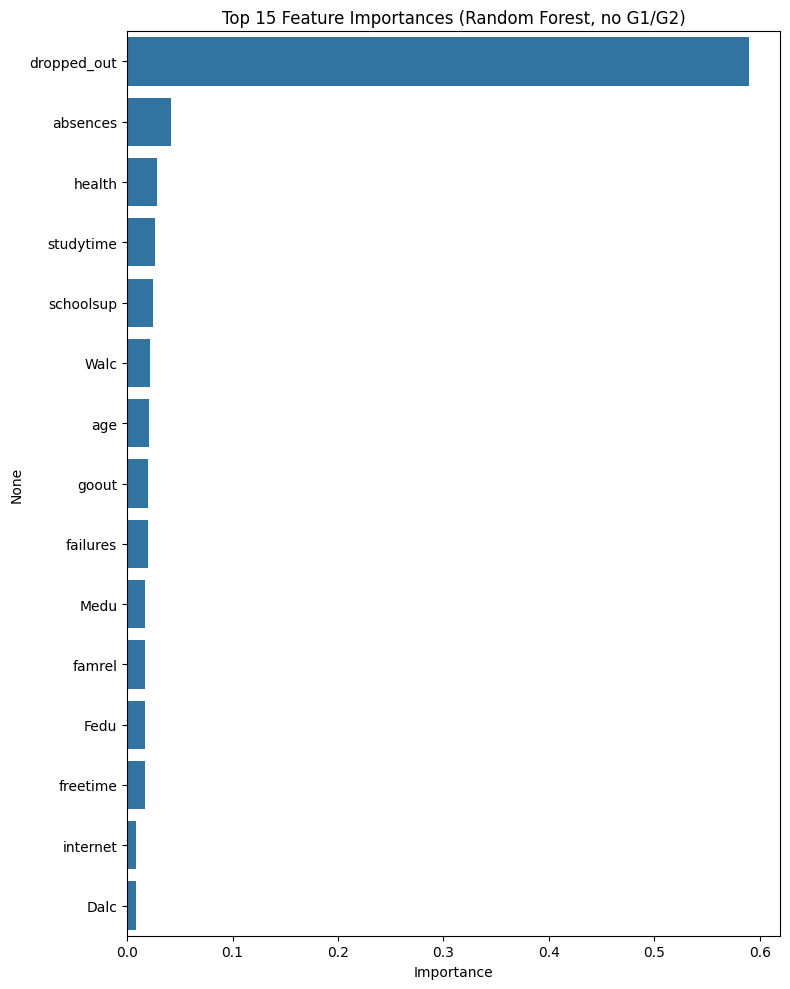

In [7]:
# ---- 3. Feature importance from Random Forest (no-grades variant) ----
import matplotlib.pyplot as plt
import seaborn as sns
rf_no_grades = RandomForestRegressor(random_state=42, n_estimators=200)
rf_no_grades.fit(X_train2, y_train2)

importances = pd.Series(rf_no_grades.feature_importances_, index=X_train2.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index)
plt.title("Top 15 Feature Importances (Random Forest, no G1/G2)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [8]:
# ---- 4. Lasso coefficients as a cross-check (which features got zeroed out) ----
lasso_final = Lasso(alpha=0.1)
lasso_final.fit(X_train2, y_train2)

coef_series = pd.Series(lasso_final.coef_, index=X_train2.columns)
print("Non-zero Lasso coefficients:")
print(coef_series[coef_series != 0].sort_values())

Non-zero Lasso coefficients:
dropped_out     -10.138545
schoolsup        -1.059803
failures         -0.497759
absences         -0.301484
famsup           -0.296781
goout            -0.222006
Walc             -0.209995
age              -0.104095
health           -0.084719
famrel            0.024626
Mjob_services     0.178804
internet          0.182508
sex               0.207708
studytime         0.212024
Medu              0.324502
dtype: float64


In [10]:
from sklearn.model_selection import GridSearchCV

# ---- 1. Hyperparameter tuning: Random Forest, no-grades variant ----
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)
rf_grid.fit(features_no_grades, target)

print("Best params:", rf_grid.best_params_)
print("Best CV MAE:", -rf_grid.best_score_)

best_rf_no_grades = rf_grid.best_estimator_

Best params: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best CV MAE: 2.215260132451559


In [11]:
# ---- 2. Same tuning for the with-grades variant, for comparison ----
rf_grid_wg = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)
rf_grid_wg.fit(features_with_grades, target)

print("Best params (with grades):", rf_grid_wg.best_params_)
print("Best CV MAE (with grades):", -rf_grid_wg.best_score_)

best_rf_with_grades = rf_grid_wg.best_estimator_

Best params (with grades): {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best CV MAE (with grades): 0.6319847413374593


In [12]:
# ---- 3. Final comparison table across everything you've built ----
results = []

def evaluate(model, X, y, label):
    mae_scores = -cross_val_score(model, X, y, cv=kf, scoring="neg_mean_absolute_error")
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring="r2")
    results.append({
        "Model": label,
        "MAE (mean)": round(mae_scores.mean(), 3),
        "MAE (std)": round(mae_scores.std(), 3),
        "R² (mean)": round(r2_scores.mean(), 3),
        "R² (std)": round(r2_scores.std(), 3)
    })

evaluate(LinearRegression(), features_with_grades, target, "Linear Regression (with G1/G2)")
evaluate(LinearRegression(), features_no_grades, target, "Linear Regression (no G1/G2)")
evaluate(Ridge(alpha=1.0), features_no_grades, target, "Ridge (no G1/G2)")
evaluate(Lasso(alpha=0.1), features_no_grades, target, "Lasso (no G1/G2)")
evaluate(RandomForestRegressor(random_state=42), features_with_grades, target, "Random Forest (with G1/G2, default)")
evaluate(RandomForestRegressor(random_state=42), features_no_grades, target, "Random Forest (no G1/G2, default)")
evaluate(best_rf_with_grades, features_with_grades, target, "Random Forest (with G1/G2, tuned)")
evaluate(best_rf_no_grades, features_no_grades, target, "Random Forest (no G1/G2, tuned)")

results_df = pd.DataFrame(results).sort_values("MAE (mean)")
results_df

,Model,MAE (mean),MAE (std),R² (mean),R² (std)
6,"Random Forest (with G1/G2, tuned)",0.634,0.065,0.964,0.009
4,"Random Forest (with G1/G2, default)",0.641,0.069,0.963,0.010
0,Linear Regression (with G1/G2),0.937,0.062,0.929,0.012
7,"Random Forest (no G1/G2, tuned)",2.128,0.223,0.630,0.049
5,"Random Forest (no G1/G2, default)",2.137,0.231,0.624,0.048
3,Lasso (no G1/G2),2.299,0.213,0.609,0.047
2,Ridge (no G1/G2),2.305,0.194,0.596,0.064
1,Linear Regression (no G1/G2),2.315,0.208,0.593,0.068


In [22]:
# ---- Export the results table as CSV too, for easy copy into README/report ----
results_df.to_csv("../reports/model_comparison.csv", index=False)
print(results_df.to_markdown(index=False))  # paste this directly into README.md

| Model                               |   MAE (mean) |   MAE (std) |   R² (mean) |   R² (std) |
|:------------------------------------|-------------:|------------:|------------:|-----------:|
| Random Forest (with G1/G2, tuned)   |        0.634 |       0.065 |       0.964 |      0.009 |
| Random Forest (with G1/G2, default) |        0.641 |       0.069 |       0.963 |      0.01  |
| Linear Regression (with G1/G2)      |        0.937 |       0.062 |       0.929 |      0.012 |
| Random Forest (no G1/G2, tuned)     |        2.128 |       0.223 |       0.63  |      0.049 |
| Random Forest (no G1/G2, default)   |        2.137 |       0.231 |       0.624 |      0.048 |
| Lasso (no G1/G2)                    |        2.299 |       0.213 |       0.609 |      0.047 |
| Ridge (no G1/G2)                    |        2.305 |       0.194 |       0.596 |      0.064 |
| Linear Regression (no G1/G2)        |        2.315 |       0.208 |       0.593 |      0.068 |


In [13]:
# ---- 4. Save the final chosen model ----
import joblib

# Pick whichever row has the best MAE/R² balance from results_df — 
# typically tuned RF no-grades is your "real" result, tuned RF with-grades 
# is your upper-bound sanity check
joblib.dump(best_rf_no_grades, "../models/final_rf_no_grades.pkl")
joblib.dump(best_rf_with_grades, "../models/final_rf_with_grades.pkl")

print("Models saved.")

Models saved.


In [14]:
# ---- 1. Final train/test split for diagnostics (separate from CV) ----
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    features_no_grades, target, test_size=0.2, random_state=42
)

best_rf_no_grades.fit(X_train_final, y_train_final)
preds_final = best_rf_no_grades.predict(X_test_final)

mae_final = mean_absolute_error(y_test_final, preds_final)
rmse_final = np.sqrt(mean_squared_error(y_test_final, preds_final))
r2_final = r2_score(y_test_final, preds_final)

print(f"Final Random Forest (no G1/G2): MAE={mae_final:.2f}, RMSE={rmse_final:.2f}, R²={r2_final:.2f}")

Final Random Forest (no G1/G2): MAE=2.48, RMSE=3.00, R²=0.56


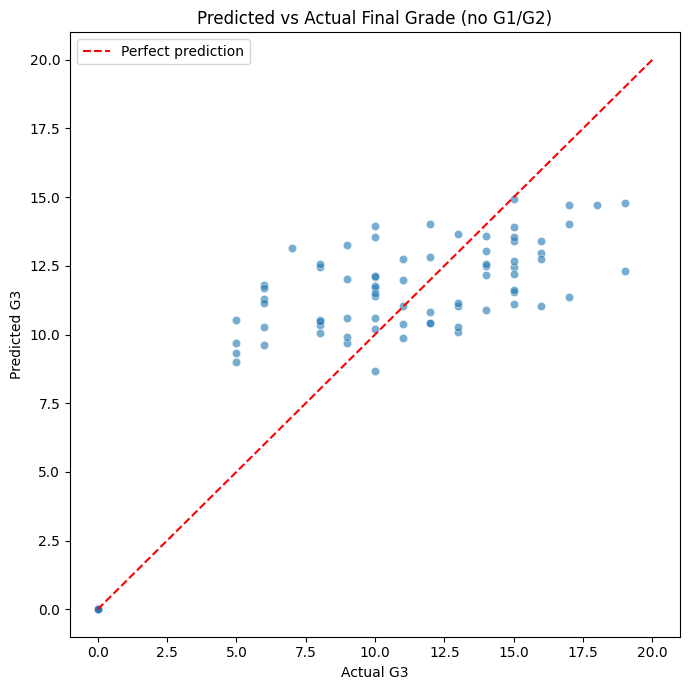

In [15]:
# ---- 2. Predicted vs Actual plot ----
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test_final, y=preds_final, alpha=0.6)
plt.plot([0, 20], [0, 20], "r--", label="Perfect prediction")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Predicted vs Actual Final Grade (no G1/G2)")
plt.legend()
plt.tight_layout()
plt.show()

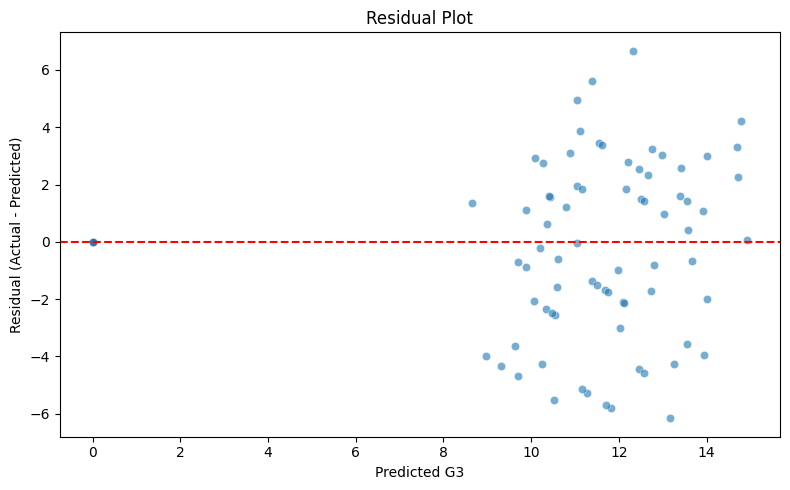

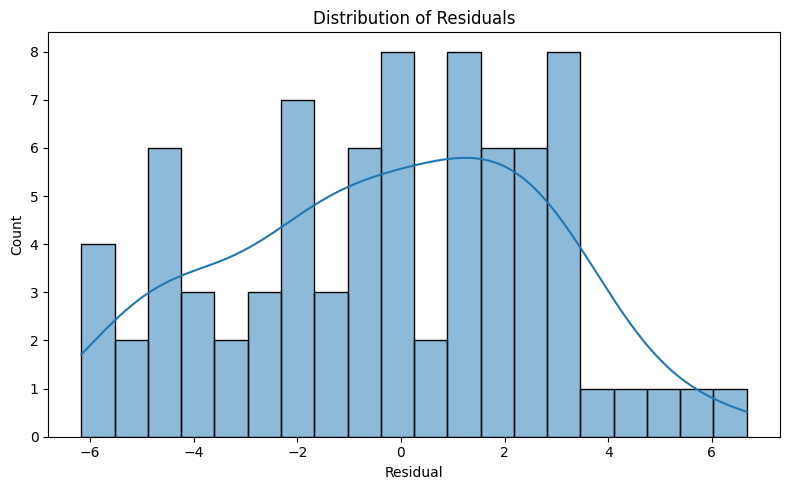

In [16]:
# ---- 3. Residual plot ----
residuals = y_test_final - preds_final

plt.figure(figsize=(8, 5))
sns.scatterplot(x=preds_final, y=residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted G3")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

# Residual distribution
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=20, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()

In [17]:
# ---- 4. Check specifically how the model handles the G3=0 dropout cases ----
# This is the group your earlier EDA flagged — worth a dedicated look
dropout_mask = y_test_final == 0
print(f"Number of true dropouts (G3=0) in test set: {dropout_mask.sum()}")
print(f"Model's predictions for those cases: {preds_final[dropout_mask]}")
print(f"Mean error on dropout cases: {np.mean(np.abs(y_test_final[dropout_mask] - preds_final[dropout_mask])):.2f}")
print(f"Mean error on non-dropout cases: {np.mean(np.abs(y_test_final[~dropout_mask] - preds_final[~dropout_mask])):.2f}")

Number of true dropouts (G3=0) in test set: 5
Model's predictions for those cases: [0. 0. 0. 0. 0.]
Mean error on dropout cases: 0.00
Mean error on non-dropout cases: 2.65


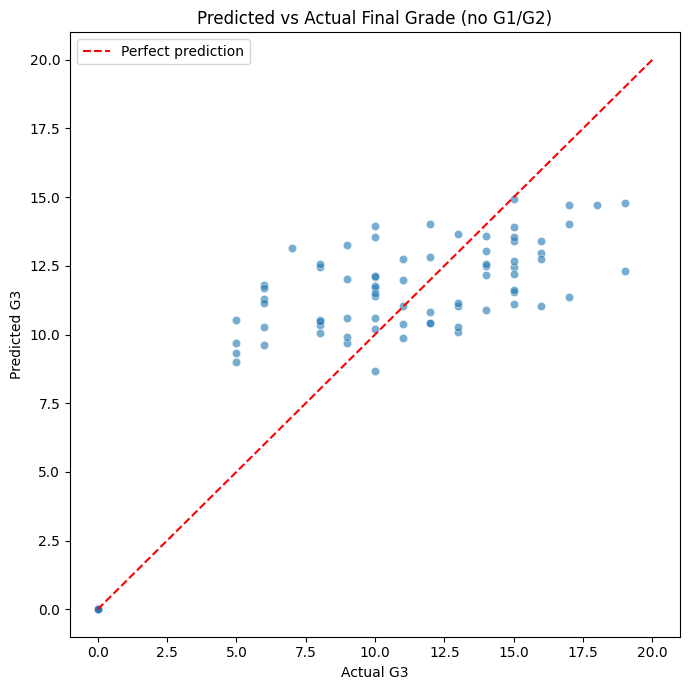

In [19]:
# ---- Save diagnostic plots for the README ----
import os
os.makedirs("../reports/figures", exist_ok=True)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test_final, y=preds_final, alpha=0.6)
plt.plot([0, 20], [0, 20], "r--", label="Perfect prediction")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Predicted vs Actual Final Grade (no G1/G2)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/predicted_vs_actual.png", dpi=150)
plt.show()

# repeat pattern for residual plot and feature importance plot,
# saving each to reports/figures/ before plt.show()

In [23]:
# ---- Save everything the frontend needs ----
import joblib

joblib.dump(best_rf_no_grades, "../models/final_rf_no_grades.pkl")
joblib.dump(scaler2, "../models/scaler_no_grades.pkl")
joblib.dump(list(features_no_grades.columns), "../models/feature_columns_no_grades.pkl")
joblib.dump(numeric_cols_no_grades, "../models/numeric_cols_no_grades.pkl")

print("Model artifacts saved to ../models/")

Model artifacts saved to ../models/
